<a href="https://colab.research.google.com/github/DeviSharanyaPasala/Spotting-Anomalous-Behaviour/blob/main/Spotting_Anomalous_Behaviour.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Import Required Libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, ConvLSTM2D, Conv3D
from tensorflow.keras.optimizers import Adam
import zipfile

print("✅ Drive mounted and libraries imported successfully.")


Mounted at /content/drive
✅ Drive mounted and libraries imported successfully.


In [2]:
# Extract Dataset from Google Drive
zip_path = "/content/drive/MyDrive/undergrad major project/Spotting Anomalous Behaviour.zip"
extract_path = "/content/drive/MyDrive/undergrad major project/Spotting_Anomalous_Behaviour"

import zipfile, os

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
        print("✅ Dataset extracted successfully to Google Drive.")
else:
    print("✅ Dataset already extracted at:", extract_path)

✅ Dataset already extracted at: /content/drive/MyDrive/undergrad major project/Spotting_Anomalous_Behaviour


In [3]:
# Define Helper Functions

def load_frames(folder_path):
    """
    Loads all image frames from a folder, resizes to 227×227,
    converts to grayscale, and normalizes pixel values.
    """
    frames = []
    for frame_file in sorted(os.listdir(folder_path)):
        img_path = os.path.join(folder_path, frame_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        resized = cv2.resize(img, (227, 227))
        frames.append(resized)
    frames = np.array(frames, dtype=np.float32) / 255.0
    return frames.reshape(-1, 227, 227, 1)


def create_sequences(data, seq_length=10):
    """
    Creates overlapping frame sequences for spatio-temporal learning.
    """
    sequences = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences)


In [4]:
# Build ConvLSTM Autoencoder Model

def build_model():
    """
    Builds a ConvLSTM-based Autoencoder to learn normal motion patterns.
    """
    input_shape = (10, 227, 227, 1)
    inp = Input(shape=input_shape)

    x = ConvLSTM2D(64, (3, 3), activation='relu', padding='same', return_sequences=True)(inp)
    x = ConvLSTM2D(32, (3, 3), activation='relu', padding='same', return_sequences=True)(x)
    out = Conv3D(1, (3, 3, 3), activation='sigmoid', padding='same')(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

print("✅ Model architecture function defined.")


✅ Model architecture function defined.


In [5]:
# Define Dataset Paths using Google Drive
base_path = "/content/drive/MyDrive/undergrad major project/Spotting_Anomalous_Behaviour/UCSD_Anomaly_Dataset.v1p2/UCSDped1"

train_root = os.path.join(base_path, "Train")
test_root = os.path.join(base_path, "Test")
test_folder = os.path.join(test_root, "Test001")

if os.path.exists(train_root) and os.path.exists(test_folder):
    print("✅ Training and testing folders found successfully in Drive.")
else:
    print("❌ Please verify the folder structure under UCSDped1/Train and UCSDped1/Test.")

✅ Training and testing folders found successfully in Drive.


In [6]:
# Load frames from multiple TrainXXX folders

def load_multiple_train_folders(train_root, limit_folders=10):
    """
    Loads frames from multiple training folders (Train001–Train010 by default)
    and returns a combined array of frames.
    """
    all_frames = []
    subfolders = sorted([f for f in os.listdir(train_root) if f.startswith("Train")])[:limit_folders]
    for folder in subfolders:
        folder_path = os.path.join(train_root, folder)
        print("Loading frames from:", folder_path)
        frames = load_frames(folder_path)
        all_frames.extend(frames)
    all_frames = np.array(all_frames)
    return all_frames

train_frames = load_multiple_train_folders(train_root, limit_folders=10)
train_sequences = create_sequences(train_frames)

print("✅ Training data prepared successfully.")
print("Total frames:", train_frames.shape[0])
print("Training sequence shape:", train_sequences.shape)

Loading frames from: /content/drive/MyDrive/undergrad major project/Spotting_Anomalous_Behaviour/UCSD_Anomaly_Dataset.v1p2/UCSDped1/Train/Train001
Loading frames from: /content/drive/MyDrive/undergrad major project/Spotting_Anomalous_Behaviour/UCSD_Anomaly_Dataset.v1p2/UCSDped1/Train/Train002
Loading frames from: /content/drive/MyDrive/undergrad major project/Spotting_Anomalous_Behaviour/UCSD_Anomaly_Dataset.v1p2/UCSDped1/Train/Train003
✅ Training data prepared successfully.
Total frames: 165
Training sequence shape: (155, 10, 227, 227, 1)


In [7]:
# Train the ConvLSTM Autoencoder

model = build_model()
print("🚀 Starting model training...")
history = model.fit(train_sequences, train_sequences, epochs=5, batch_size=2)
print("✅ Model training completed.")

🚀 Starting model training...
Epoch 1/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 78s 794ms/step - loss: 0.0330
Epoch 2/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 52s 669ms/step - loss: 0.0039
Epoch 3/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 83s 685ms/step - loss: 0.0015
Epoch 4/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 52s 670ms/step - loss: 0.0011
Epoch 5/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 53s 677ms/step - loss: 7.0137e-04
✅ Model training completed.


In [8]:
# Test the model on one test sequence (Test001)

test_frames = load_frames(test_folder)
test_sequences = create_sequences(test_frames)

reconstructed = model.predict(test_sequences)
mse = np.mean(np.power(test_sequences - reconstructed, 2), axis=(1, 2, 3, 4))

threshold = np.mean(mse) + 2 * np.std(mse)
anomalies = np.where(mse > threshold)[0]

print("Anomalous frame indices:", anomalies)

6/6 ━━━━━━━━━━━━━━━━━━━━ 52s 6s/step
Anomalous frame indices: [133 134 135 136 137 138 139 140 141]


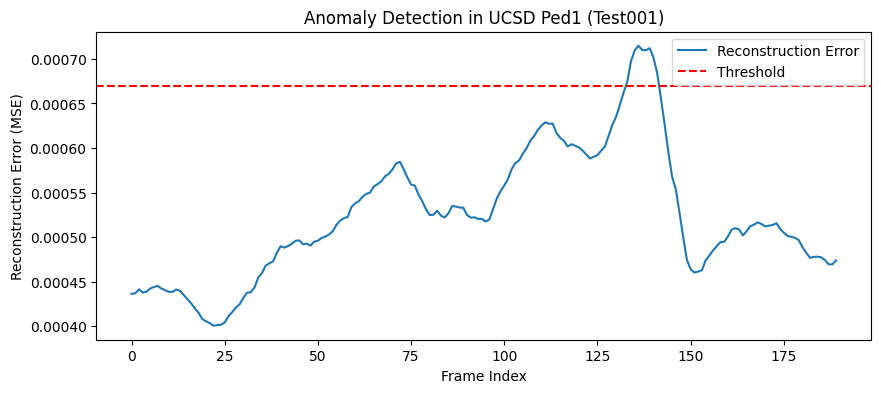

✅ Execution complete – the plot shows frames flagged as anomalies.


In [9]:
# Visualize the reconstruction error and threshold

plt.figure(figsize=(10, 4))
plt.plot(mse, label="Reconstruction Error")
plt.axhline(y=threshold, color="r", linestyle="--", label="Threshold")
plt.title("Anomaly Detection in UCSD Ped1 (Test001)")
plt.xlabel("Frame Index")
plt.ylabel("Reconstruction Error (MSE)")
plt.legend()
plt.show()

print("✅ Execution complete – the plot shows frames flagged as anomalies.")